# Session 2
In this session, we will use the prepared dataset of EGFR activity data from Session 1 to train ML models that predict the pIC50 value of a given molecule. 

**Content:**
1. Featuration
2. Training a random forest (RF)
    1. Data splitting
    2. Training
    3. Model performance evaluation
    4. Interpreting the forest
4. Model comparision
    1. K-fold cross validation
    2. Comparing the RF with Ridge regression
    2. Model section with a Grid Search

In [20]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import matplotlib.pyplot as plt
import seaborn as sns

First, we reload the prepared data from Session 1 into a DataFrame:

In [21]:
egfr_activities_df = pd.read_csv(
    "https://github.com/volkamerlab/cic_summerschool_2025/raw/refs/heads/main/data/EGFR-activities-prepared.csv",
    index_col=0,
)
egfr_activities_df.head()

,pIC50,molecule_dictionary.chembl_id,canonical_smiles
0,6.339419,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1
1,5.484537,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
2,5.136677,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1
3,6.494850,CHEMBL102726,c1ccc(CNc2ncnc3ccccc23)cc1
4,5.387216,CHEMBL103552,O=C(O)c1cc(N(Cc2ccccc2O)Cc2cc(O)ccc2O)ccc1O


## Featuration
To use molecules in machine learning models, we need to encode them numerically. We do this by generating fingerprint bit vectors for each molecule. Each molecule is then represented as a vector of fixed length ($1024$ in our example).

In [22]:
fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)

egfr_activities_df["morgan_fp"] = egfr_activities_df["canonical_smiles"].apply(
    lambda smiles: fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles))
)
egfr_activities_df.head()

,pIC50,molecule_dictionary.chembl_id,canonical_smiles,morgan_fp
0,6.339419,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,5.484537,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,5.136677,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,6.494850,CHEMBL102726,c1ccc(CNc2ncnc3ccccc23)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5.387216,CHEMBL103552,O=C(O)c1cc(N(Cc2ccccc2O)Cc2cc(O)ccc2O)ccc1O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Training a random forest (RF)
We aim to train a function that takes a bit vector as input and predicts the pIC50 value.

### Data splitting
Our goal is to be learn a (machine learning) model that generalizes well.

Therefore, we split our dataset into 2 subsets:
* A larger subset on which we will train our model called the *training set*.
* A smaller subset on which we will *test* the model. It is important that we evaluate our model on a subset of the data it has **never seen before** to ensure that we are not overfitting the data and that our model can generalize well to secret data.

Here, we will randomly split the data. However, note that usually in a real world scenaria, one should avoid random splitting in this area to avoid data leacage, e.g., since molecules with similar scaffold have been already seen during training. (TODO rephrase)

**Random splitting:**

We use the `train_test_split` function of the **sklearn** library to split 80% of the data for training and 20% for testing *randomly*. 

In [23]:
from sklearn.model_selection import train_test_split

df_train_random, df_test_random = train_test_split(egfr_activities_df, test_size=0.2, random_state=42)
print(f"{len(df_train_random)} traing samples, {len(df_test_random)} test samples")

4857 traing samples, 1215 test samples


**Scaffold splitting:**
 
 Insetad of just dividng the data randomly, we are going to divide it up based on the chemical scaffold of the ligands. This ensures that molecules with similar core structur(scaffolds) are kept together in either the training or test set, but not both. This is important in drug discovery because it ensures that the model is evaluated on ligands with new scaffolds it has not seen during training. 

In [24]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# generate Bemis-Murcko scaffold from a SMILES string
def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

Add the scaffolds to the dataset:

In [25]:
egfr_activities_df['scaffold'] = egfr_activities_df['canonical_smiles'].apply(generate_scaffold)

In [26]:
def scaffold_split(df, test_size=0.1, random_state=42):
    """Perform a scaffold split to separate the dataset into train and test sets."""
    scaffolds = df['scaffold'].unique() # get unique scaffolds

    train_scaffolds, test_scaffolds = train_test_split(scaffolds, test_size=test_size, random_state=random_state)

    train_data = df[df['scaffold'].isin(train_scaffolds)]
    test_data = df[df['scaffold'].isin(test_scaffolds)]

    return train_data, test_data

In [27]:
# scaffold split with train and test sets
df_train_scaffold, df_test_scaffold = scaffold_split(egfr_activities_df)

# check the sizes of the resulting train and test sets
print(f"Training set size: {df_train_scaffold.shape}")
print(f"Test set size: {df_test_scaffold.shape}")

print(f"Intersection between train and test set: {set(df_train_scaffold['canonical_smiles']).intersection(df_test_scaffold['canonical_smiles'])}")

Training set size: (5613, 5)
Test set size: (459, 5)
Intersection between train and test set: set()


We convert our fingerprints (X) and pIC50 (y) values into **NumPy** arrays. **NumPy** allows to create vectors (1D), matrices (2D), tensors (>= 3D) in the form of arrays. Further it offers a large collection of efficient numerical operations on arrays, which is crucial for machine learning.

In [28]:
import numpy as np

X_train, y_train = np.stack(df_train_scaffold["morgan_fp"]), np.array(df_train_scaffold["pIC50"])
X_test, y_test = np.stack(df_test_scaffold["morgan_fp"]), np.array(df_test_scaffold["pIC50"])

In [29]:
print(f"Dimentions of training input: {X_train.shape}")
print(f"Dimentions of training output: {y_train.shape}")
print(f"Dimentions of training input: {X_test.shape}")
print(f"Dimentions of training output: {y_test.shape}")

Dimentions of training input: (5613, 1024)
Dimentions of training output: (5613,)
Dimentions of training input: (459, 1024)
Dimentions of training output: (459,)


### Training 
With **sklearn**, we first initialize the model, fit it to the training data using the `fit`-function, and then predict on new inputs using the `predict`-function of the model.

Let's first initialize the RF with it's default parameters:

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Next, we fit (train) the RF to our training data:

In [31]:
# fit the RF
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

The trained RF is now written to `rf_model`. We can use it's member functionc `predict` to predict the pIC50 values against EGFR for given molecules by their fingerprint.

In [32]:
smiles_caffeine = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
caffeine_fp = fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles_caffeine))

caffeine_activity = rf_model.predict([caffeine_fp])

print(f"Predicted pIC50 of caffein against EGFR: {caffeine_activity[0]:.2f}")

Predicted pIC50 of caffein against EGFR: 5.61


### Model performance evaluation

First we make predictions on the test set (`X_test`) that we will later compare to the respective true labels (`y_test`) to evaluate of our model.

In [33]:
y_pred = rf_model.predict(X_test)

We compute the mean squared error (MSE) as well as the $R^2$ using the respective functions from the `sklearn.metrics` module.

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r_square = r2_score(y_test, y_pred)
print(f"Test (MSE): {mse}")
print(f"Test (R^2): {r_square}")

Test (MSE): 0.7533376400805097
Test (R^2): 0.5897408979793359


Let's also visualize these results:

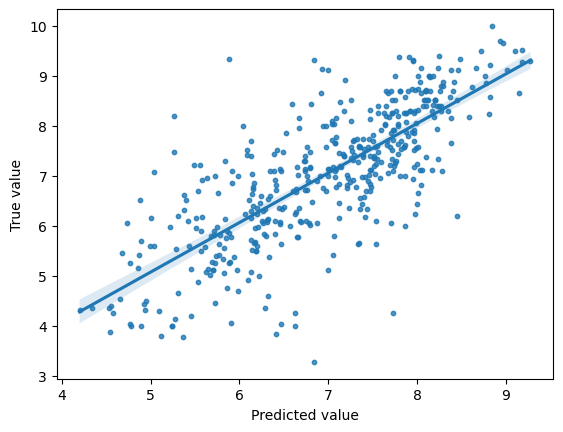

In [35]:
sns.regplot(x=y_pred, y=y_test, scatter_kws={"s": 10})
plt.ylabel("True value")
plt.xlabel("Predicted value")
plt.show()

### Interpreting the forest
Apart from evaluating model performance, we might also be interested in understanding what the model learned. One way to do this is by looking at **feature importance** — intuitively, this tells us which input features (fingerprint bits) had the greatest influence on the model’s predictions.

Top 3 bits: [428 128 621]


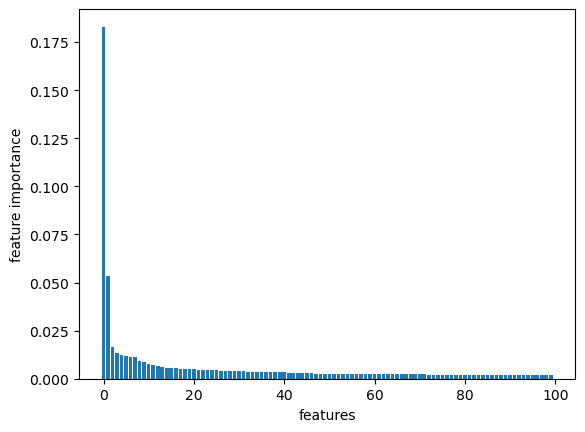

In [36]:
plt.bar(range(100), sorted(rf_model.feature_importances_, reverse=True)[:100])
plt.ylabel("feature importance")
plt.xlabel("features")
top3bits = np.argsort(rf_model.feature_importances_)[:-4:-1]
print(f"Top 3 bits: {top3bits}")

Let's look for an example substructure for the most import bit:

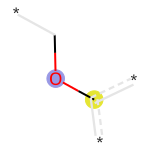

In [37]:
top_bit = top3bits[0]
top_bit_active = df_train_scaffold[
    df_train_scaffold["morgan_fp"].apply(lambda fp: fp[top_bit] == 1)
].reset_index(drop=True)
example_mol = Chem.MolFromSmiles(top_bit_active["canonical_smiles"][0])
ao = AllChem.AdditionalOutput()
ao.CollectBitInfoMap()
fp = fpgen.GetFingerprint(example_mol, additionalOutput=ao)
bi = ao.GetBitInfoMap()
Draw.DrawMorganBit(example_mol, top_bit, bi, useSVG=True)

##  Model comparison

### K-fold cross validation
To have a better estimate on how a model generalized, i.e., performs on secret data, one often performs a cross validation instead of a simple train/test split. A common splitting technique is k-fold splt. In k-fold splits, the data is splitted into k subsets, in such a way that each data point is part of the test set exactly once.

For example, if we choose to do a 5-fold split, the summary of the process would be:

**Fold 1**: Train on Folds 2, 3, 4, 5 | Test on Fold 1

**Fold 2**: Train on Folds 1, 3, 4, 5 | Test on Fold 2

**Fold 3**: Train on Folds 1, 2, 4, 5 | Test on Fold 3

**Fold 4**: Train on Folds 1, 2, 3, 5 | Test on Fold 4

**Fold 5**: Train on Folds 1, 2, 3, 4 | Test on Fold 5

**5-fold CV with random split:**

In [38]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)

X, y = np.stack(egfr_activities_df["morgan_fp"]), np.array(egfr_activities_df["pIC50"])

# perform K-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):

    # split the data into training and test sets for this fold
    X_train, y_train = X[train_index], y[train_index]
    X_test, y_test = X[test_index], y[test_index]

    print(f"Fold {fold+1}:")
    print(f"  Training fold size: {X_train.shape}")
    print(f"  Test fold size: {X_test.shape}")

    # fit the model on X_train, y_train

    # evaluate the model on X_test, y_test

Fold 1:
  Training fold size: (4857, 1024)
  Test fold size: (1215, 1024)
Fold 2:
  Training fold size: (4857, 1024)
  Test fold size: (1215, 1024)
Fold 3:
  Training fold size: (4858, 1024)
  Test fold size: (1214, 1024)
Fold 4:
  Training fold size: (4858, 1024)
  Test fold size: (1214, 1024)
Fold 5:
  Training fold size: (4858, 1024)
  Test fold size: (1214, 1024)


Note that the test set in each fold effectively serves the role of the validation set. For each fold, the model is trained on K-1 folds and tested on the remaining fold. Since this testing fold is never seen during training, it acts like a validation set to evaluate the model's performance on secret data.

### Comparing the RF with Ridge regression
Let's see with of the following model generailized the best on the given data using a 5-fold CV: 
* RF
* Ridge Regression

**Note:** instead of manually iterating through the folds, we could also use the `cross_val_score` function from scikit-learn when using random splitting. This function performs k-fold cross-validation automatically: for each fold, it trains the model on the training split and evaluates it on the validation split. As output, it returns the evaluation scores for all folds.

**Random Forest:**

In [39]:
from sklearn.model_selection import cross_val_score

rf_mse_cv = -cross_val_score(rf_model, X, y, scoring="neg_mean_squared_error", n_jobs=-1)

print(f"Mean validation MSE (RF): {rf_mse_cv.mean():.2f}±{rf_mse_cv.std():.2f}")

Mean validation MSE (RF): 1.16±0.17


**Ridge regression**:

In [40]:
from sklearn.linear_model import Ridge

ridge = Ridge(solver="svd")

ridge_mse_cv = -cross_val_score(ridge, X, y, scoring="neg_mean_squared_error", n_jobs=-1)

print(
    f"Mean validation MSE (Ridge regression): {ridge_mse_cv.mean():.2f}±{ridge_mse_cv.std():.2f}"
)

Mean validation MSE (Ridge regression): 1.75±0.19


We can also visualize the results in a boxplot:

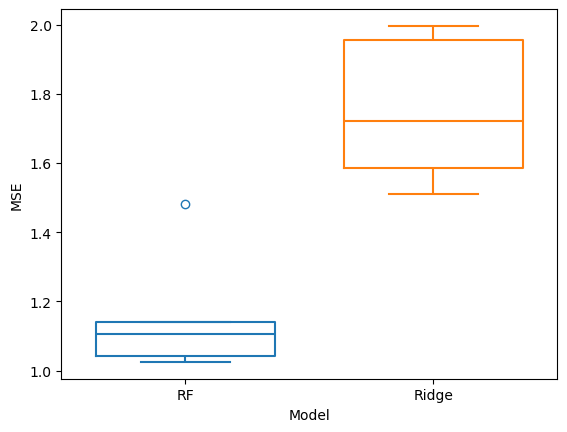

In [41]:
sns.boxplot({"RF": rf_mse_cv, "Ridge": ridge_mse_cv}, fill=False, gap=0.1)
plt.xlabel("Model")
plt.ylabel("MSE")
plt.show()

### Hyperparameter tuning unsing grid search
So far, we have relied on default model parameters. However, these hyperparameters — for example, the number of estimators in a Random Forest — can be adjusted to *better* fit the structure of the given data. Finding the best combination of hyperparameters can be quite challenging, especially in terms of runtime. When the search space is relatively small, a **grid search** (i.e., an exhaustive search over all possible parameter combinations) is a suitable option. To select the best model from this search, one typically uses k-fold cross-validation, provided that runtime requirements allow it.

In [42]:
from sklearn.model_selection import ParameterGrid

param_grid = ParameterGrid({"n_estimators": [100, 300], "max_depth": [30, 50]})

for parameters in param_grid:
    print(f"Parameters: {parameters}")
    # perform CV on the model and report the performance

Parameters: {'max_depth': 30, 'n_estimators': 100}
Parameters: {'max_depth': 30, 'n_estimators': 300}
Parameters: {'max_depth': 50, 'n_estimators': 100}
Parameters: {'max_depth': 50, 'n_estimators': 300}


We can also use Scikit's functionality that can perform parallized grid search. Note that here again we perform a random split and **not** a scaffold split.

In [43]:
from sklearn.model_selection import GridSearchCV

X, y = np.stack(egfr_activities_df["morgan_fp"]), np.array(egfr_activities_df["pIC50"])

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid={"n_estimators": [100, 300], "max_depth": [30, 50]},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,  # NOTE: this will perform the grid search on all available processors in parallel
)

In [44]:
grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV MSE: {-grid_search.best_score_:.3f}")

Best parameters: {'max_depth': 50, 'n_estimators': 300}
Best CV MSE: 1.158


In the steps above, we selected and tuned the best model based on the validation scores from cross-validation. However, this still means that the same data was used for both model selection and performance estimation. To obtain an unbiased estimate of the true performance, we need an entirely separate test dataset that was not involved in the training or model selection process.
For this purpose, we provide an additional EGFR activity dataset of *secret* molecules [EGFR-activities-secret.csv](https://github.com/volkamerlab/cic_summerschool_2025/raw/refs/heads/main/data/EGFR-activities-secret.csv).

In [45]:
egfr_activities_secret_df = pd.read_csv(
    "https://github.com/volkamerlab/cic_summerschool_2025/raw/refs/heads/main/data/EGFR-activities-secret.csv",
    index_col=0,
)

egfr_activities_secret_df["morgan_fp"] = egfr_activities_secret_df[
    "canonical_smiles"
].apply(lambda smiles: fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)))

X_secret, y_secret = np.stack(
    egfr_activities_secret_df["canonical_smiles"].apply(
        lambda smiles: fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles))
    )
), np.array(egfr_activities_secret_df["pIC50"])

best_model = grid_search.best_estimator_
y_pred_secret = best_model.predict(X_secret)

mse_secret = mean_squared_error(y_secret, y_pred_secret)
r2_secret = r2_score(y_secret, y_pred_secret)

print(f"Secret test set MSE: {mse_secret:.3f}")
print(f"Secret test set R^2: {r2_secret:.3f}")

Secret test set MSE: 0.701
Secret test set R^2: 0.596


## Excercises

### Exercise 1 (Classification)
In this exercise, we aim to train models that **classify**, whether a compound is active or not on a EGFR. To this end, we need to label our samples as active (`1`) or not active (`0`) based on their pIC50 value.

In [46]:
# Add a column 'activ' to the egrf dataframe that is 1 if the pIC50 value is greater than 7.5 else 0 (inactive)

# TODO
egfr_activities_df["activ"] = None

In [47]:
# Similar to the regression task create numpy arrays of the input X (fingerprint) and output y (activity label)

# TODO
X, y = None, None

# NOTE: this will overwrite the variables from before (regression)

In [ ]:
# Perform a 5-fold cross validation using RF classifiers 
# (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
# and report the accuracy (scoring='accuracy')

from sklearn.ensemble import RandomForestClassifier

# TODO

In [49]:
# In the lecture learned you learned about support vector machines (SVM).
# Do the same as the previous task but use a SVM instead of the RF.

# TODO

In [ ]:
# Generate a boxplot that compares the RF with SVM's accuracy. Which model generalizes the best on the given data?

# TODO

In [ ]:
# On the model, you choose, calculate the accuracy on the secret test dataset

# TODO

In [51]:
# BONUS: In the lecture, you learned about the ROC curve and the AUC.
# Scikit-learn provides the functionality to generate such a plot as well as the AUC.
# Look at https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html#sklearn.metrics.RocCurveDisplay 
# to find the corresponding functionality to generate such a ROC curve. Note that you need to import the corresponding package.

# TODO

### Exercise 2 (Scaffold-based CV)
In this notebook, we performed the CV using a random splits. However, we would like to split the data also in a scaffold-based manner.

In [52]:
# complete the following function that takes a df and a model as input and performs a 5-fold CV with scaffold splitting
# it should return a list the validation scores of each fold
# you can assume that the df frame already has a column 'scaffold'
# NOTE: the given implementation should help you to start, however, you can also implemt this in a different way

def scaffold_cross_val(model, df, verbose=True):
    scores = []
    
    scaffold_groups = egfr_activities_df.groupby('scaffold').apply(lambda x: x.index.tolist())

    # create KFold cross-validator for scaffold groups
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    #iterate over the K folds
    for fold, (train_group_index, test_group_index) in enumerate(kf.split(scaffold_groups)):
        
        # get the train and test scaffold groups
        # TODO

        # get the actual train/test indices from the scaffold groups
        # TODO

        # create train and test sets
        # TODO
        
        # create numpy arrays
        # TODO
        
        # fit the model on X_train, y_train
        # TODO

        # evaluate the model on X_test, y_test
        # TODO
        
        pass
    
    return scores

In [53]:
# use this function to perform a 5-fold CV on a RF regressor (predicting the pIC50 values)

# TODO